**Function to  extract the osm exposure with value assigned by climada to a csv file or any python readable data format over an region of interest**

**Take manila metropolitan area as the test case**

https://climada-python.readthedocs.io/en/stable/tutorial/climada_entity_Exposures_osm.html

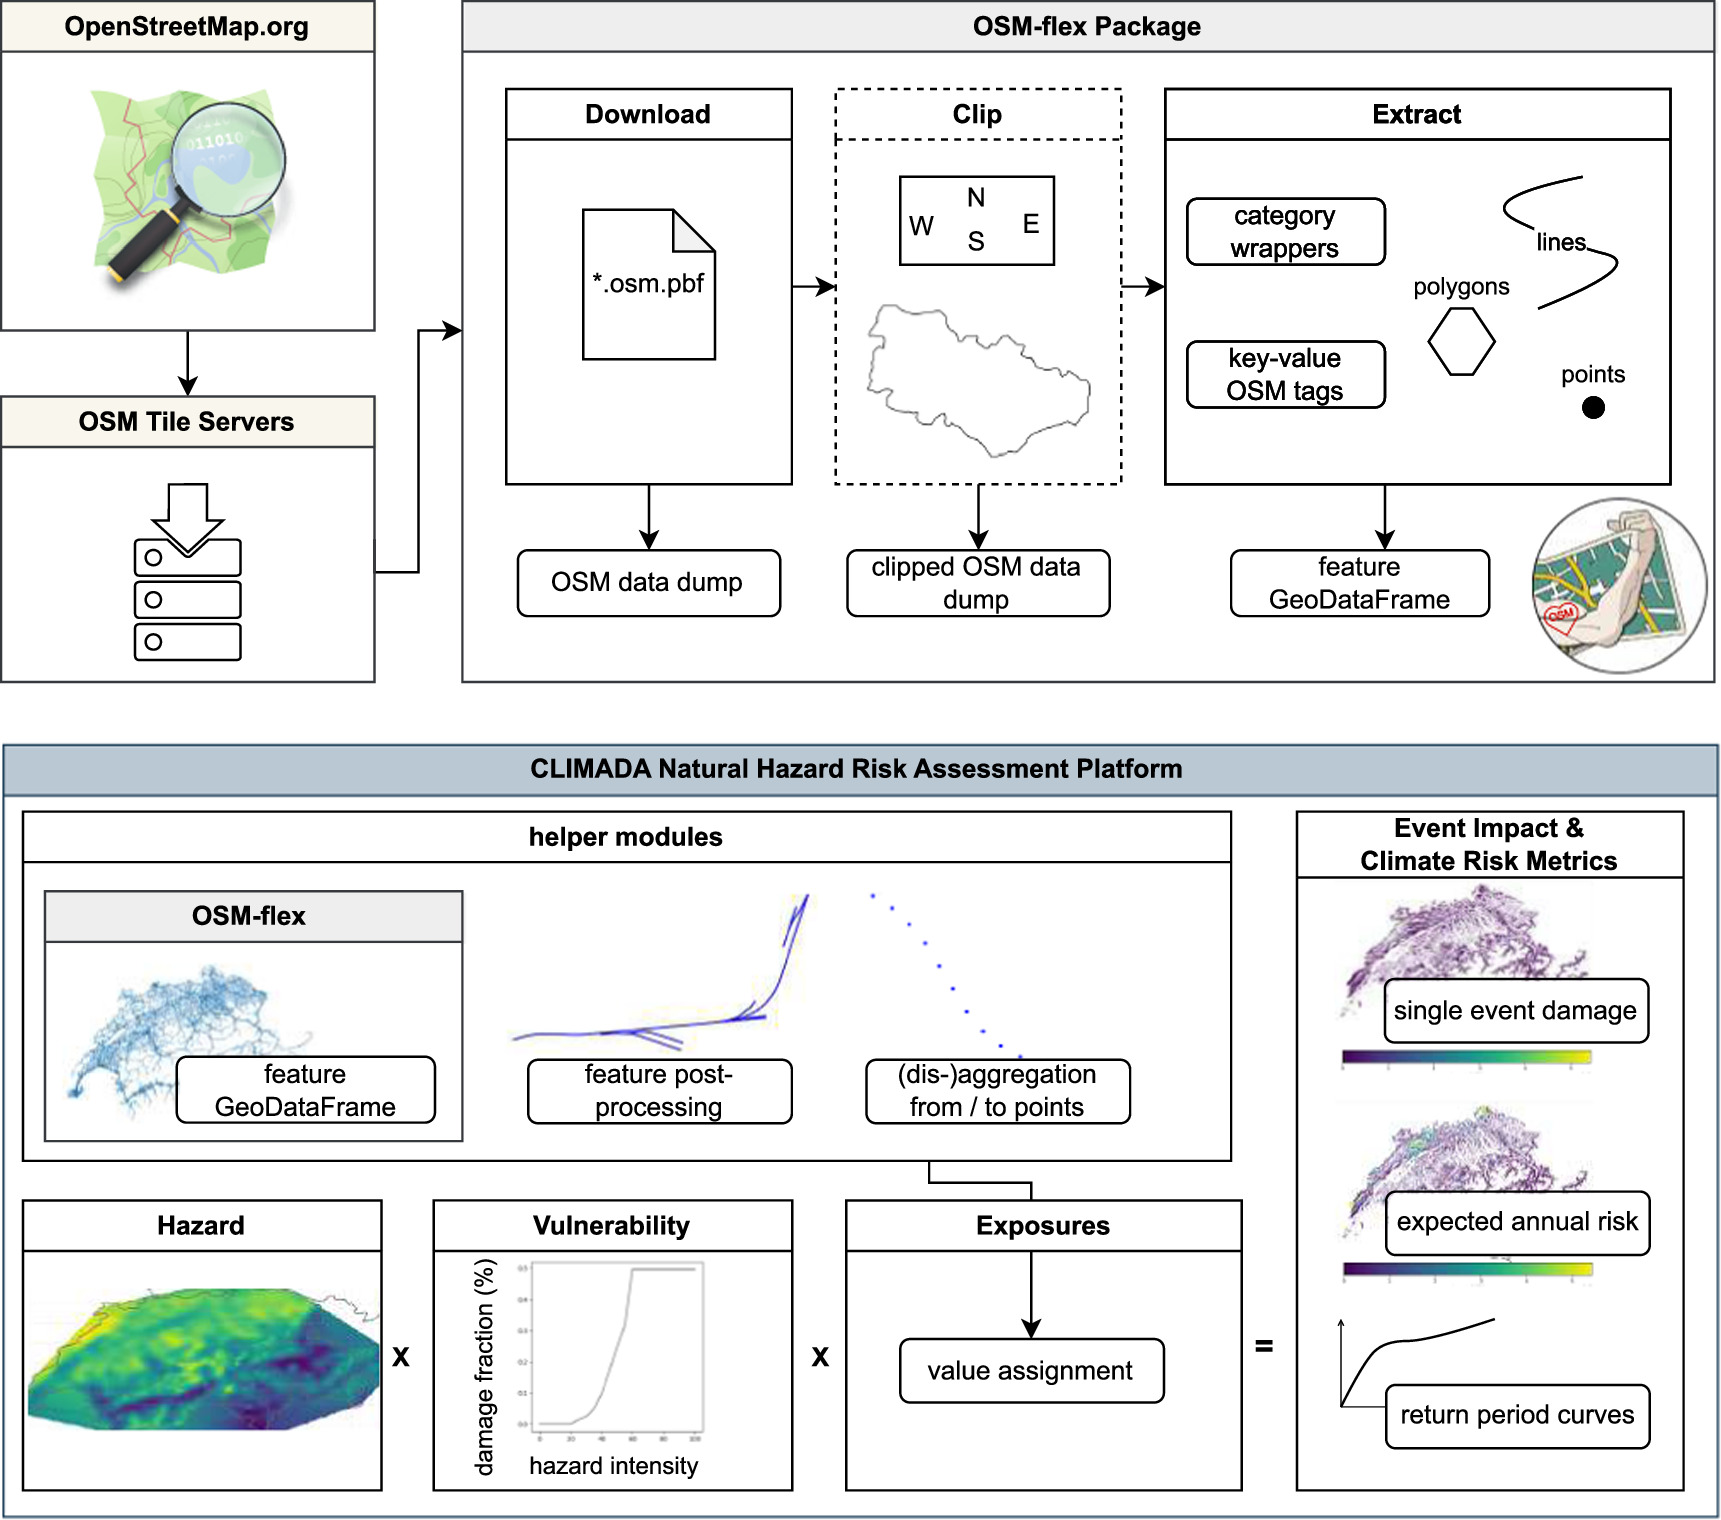

https://iopscience.iop.org/article/10.1088/2515-7620/ad15ab

# **0 Import Library**

In [7]:
!pip install osm_flex
!pip install climada
!pip install fiona

import osm_flex.download
import osm_flex.extract
import osm_flex.simplify as sy  # For preprocessing
from climada.entity import Exposures
from shapely.geometry import Polygon  # For clipping to Metro Manila bounds
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt



# **1 Focus the Manila by input the shape file and the iso3 code**

https://docs.dnb.com/partner/en-US/iso_country_codes

In [5]:
iso3 = "PHL" # input the iso3 code
path_ctr_dump = osm_flex.download.get_country_geofabrik(iso3)

In [8]:
shapefile_path = "Metro_Manila_Box.shp" # input the shape file
gdf = gpd.read_file(shapefile_path)

# Function to extract coordinates from a geometry
def extract_coordinates(geometry):
    coords = []
    if geometry.geom_type == 'Polygon':
        coords.extend(list(geometry.exterior.coords))
    elif geometry.geom_type == 'MultiPolygon':
        for poly in geometry.geoms:
            coords.extend(list(poly.exterior.coords))
    elif geometry.geom_type == 'Point':
        coords.append((geometry.x, geometry.y))
    return coords

# Collect all coordinates using a for loop
all_coordinates = []
print("Longitude,Latitude")
for index, row in gdf.iterrows():
    coords = extract_coordinates(row.geometry)
    for lon, lat in coords:
        print(f"{lon},{lat}")
        all_coordinates.append((lon, lat))

# Extract all coordinates
first_coord = all_coordinates[0]  # First coordinate
second_coord = all_coordinates[1]  # First coordinate
third_coord = all_coordinates[2]  # Third coordinate
fourth_coord = all_coordinates[3]  # First coordinate


Longitude,Latitude
120.39379207352661,14.075338118147869
120.39379207352661,14.946778538280228
121.30440398410013,14.946778538280228
121.30440398410013,14.075338118147869
120.39379207352661,14.075338118147869


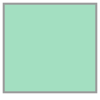

In [9]:
# Define bounding box as a Polygon (in EPSG:4326)
bounds = Polygon([first_coord, second_coord, third_coord, fourth_coord])
bounds

# **2.1 Extract the layer of interest**

Layer include 'education', 'healthcare', 'water', 'telecom', 'road', 'main_road', 'rail', 'air', 'gas', 'oil', 'power', 'wastewater', 'food', 'buildings'


In [22]:
# List of infrastructure sectors
sectors = ['education', 'healthcare', 'water', 'telecom', 'road', 'main_road', 'rail', 'air', 'gas', 'oil', 'power', 'wastewater', 'food', 'buildings']


In [ ]:
# Loop through each sector
for sector in sectors:
    try:
        # Extract critical infrastructure data with dynamic variable name
        gdf_sector = osm_flex.extract.extract_cis(path_ctr_dump, sector)

        # Set CRS to EPSG:4326
        gdf_sector = gdf_sector.to_crs(epsg=4326)

        # Clip the GeoDataFrame
        gdf_sector = gdf_sector.clip(bounds)

        # Create Exposures object
        exp_sector = Exposures(gdf_sector)

        # Save to CSV
        output_file = f"{sector}_exposures.csv"
        exp_sector.gdf.to_csv(output_file, index=False)
        print(f"Saved {sector} exposures to {output_file}")

        # Create and save plot
        fig, ax = plt.subplots(figsize=(15, 15))
        gdf_sector.plot(ax=ax, alpha=1, markersize=5, color="blue", edgecolor="blue", label="Industrial Facilities")
        ax.legend(loc="upper left")
        ax.set_title(f"{sector}_exposures Example", fontsize=25)

        # Save plot as PNG
        plot_file = f"{sector}_exposures_plot.png"
        plt.savefig(plot_file, dpi=300, bbox_inches='tight')
        plt.close(fig)
        print(f"Saved {sector} plot to {plot_file}")


    except Exception as e:
        print(f"Error processing {sector}: {str(e)}")

extract multipolygons: 100%|██████████| 285288/285288 [04:15<00:00, 1114.50it/s]


Saved education exposures to education_exposures.csv


/tmp/ipython-input-23-4141969193.py:24: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc="upper left")


Saved education plot to education_exposures_plot.png


extract multipolygons: 100%|██████████| 5278/5278 [03:21<00:00, 26.18it/s]


...

Saved food exposures to food_exposures.csv


/tmp/ipython-input-23-4141969193.py:24: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc="upper left")


Saved food plot to food_exposures_plot.png


extract multipolygons: 100%|██████████| 11199011/11199011 [20:13<00:00, 9226.20it/s] 


Saved buildings exposures to buildings_exposures.csv


# **2.2 Extract the specific class of exposure**
**Like the Industrial Facilities / Industrial Parks**

https://wiki.openstreetmap.org/wiki/Map_features

we can reference the above link to modify the code to extract specific classes of exposures from OSM using targeted queries

In [10]:
import osm_flex
import osm_flex.download
import osm_flex.extract

iso3 = "PHL"  # ISO3 code
path_dump = osm_flex.download.get_country_geofabrik(iso3)

In [11]:
osm_keys = ["landuse", "building"]
osm_query = "landuse='industrial' or building='industrial'"  # Query string for constraints
gdf_varaible = osm_flex.extract.extract(
    path_dump, "multipolygons", osm_keys, osm_query
)
gdf_varaible = gdf_varaible.to_crs(epsg=4326)

# Clip the GeoDataFrame
gdf_varaible = gdf_varaible.clip(bounds)

exp_varaible = Exposures(gdf_varaible)

# Save to CSV
output_file = f"{osm_query}_exposures.csv"
exp_varaible.gdf.to_csv(output_file, index=False)
print(f"Saved {osm_query} exposures to {output_file}")

# Create and save plot
fig, ax = plt.subplots(figsize=(15, 15))
gdf_varaible.plot(ax=ax, alpha=1, markersize=5, color="blue", edgecolor="blue", label="Industrial Facilities")
ax.legend(loc="upper left")
ax.set_title(f"{osm_query}_exposures Example", fontsize=25)

# Save plot as PNG
plot_file = f"{osm_query}_exposures_plot.png"
plt.savefig(plot_file, dpi=300, bbox_inches='tight')
plt.close(fig)
print(f"Saved {osm_query} plot to {plot_file}")

extract multipolygons: 100%|██████████| 20198/20198 [02:42<00:00, 123.94it/s]


Saved landuse='industrial' or building='industrial' exposures to landuse='industrial' or building='industrial'_exposures.csv


/tmp/ipython-input-11-589903769.py:21: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc="upper left")


Saved landuse='industrial' or building='industrial' plot to landuse='industrial' or building='industrial'_exposures_plot.png
